In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px  
import seaborn as sns
import plotly.graph_objects as go 
from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)

In [2]:
df = pd.read_csv('train.csv')
df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


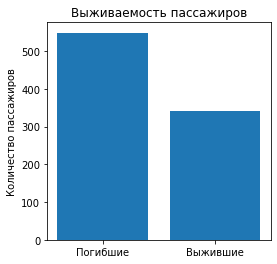

In [3]:
fig, ax = plt.subplots(figsize = (4,4))
ax.set_title('Выживаемость пассажиров')
ax.bar(df['Survived'].value_counts().rename(index={0: 'Погибшие', 1: 'Выжившие'}).index, df['Survived'].value_counts().values)
ax.set_ylabel("Количество пассажиров");

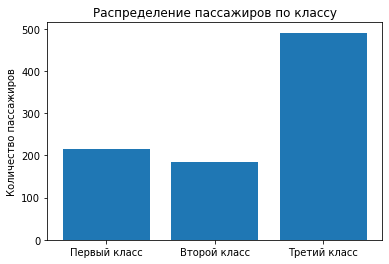

In [4]:
fig, ax = plt.subplots(figsize = (6,4))
ax.set_title('Распределение пассажиров по классу')
ax.bar(df['Pclass'].value_counts().sort_index().rename(index={1: 'Первый класс', 2: 'Второй класс', 3: 'Третий класс'}).index, df['Pclass'].value_counts().sort_index().values)
ax.set_ylabel("Количество пассажиров");

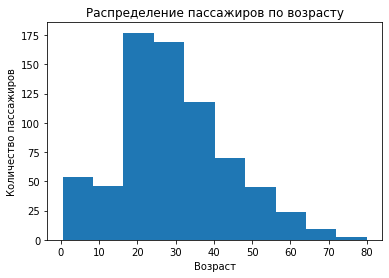

In [5]:
fig, ax = plt.subplots()

ax.hist(df['Age'])
ax.set_xlabel("Возраст")
ax.set_ylabel('Количество пассажиров')
ax.set_title('Распределение пассажиров по возрасту');

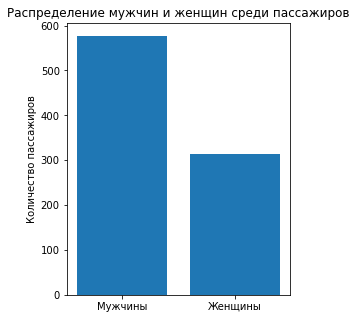

In [6]:
fig, ax = plt.subplots(figsize = (4,5))
ax.set_title('Распределение мужчин и женщин среди пассажиров')
ax.bar(df['Sex'].value_counts().rename(index={'male': 'Мужчины', 'female': 'Женщины'}).index, df['Sex'].value_counts().values)
ax.set_ylabel("Количество пассажиров");

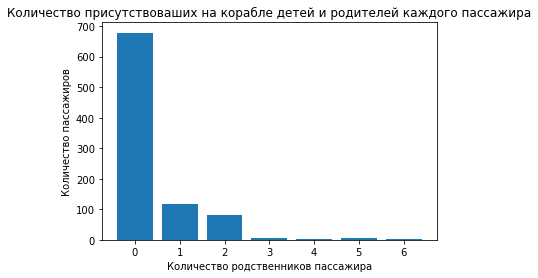

In [7]:
fig, ax = plt.subplots(figsize = (6,4))
ax.set_title('Количество присутствоваших на корабле детей и родителей каждого пассажира')
ax.bar(df['Parch'].value_counts().sort_index().index, df['Parch'].value_counts().sort_index().values)
ax.set_ylabel("Количество пассажиров");
ax.set_xlabel("Количество родственников пассажира");

Медианой выборки является возраст 28 лет.
Возраст 50% пассажиров находится в диапазоне от 20 до 38 лет.
Соответственно, пассажиры младше 20 и старше 38 лет занимают по 25% от всей выборки.
Выбросами являются значения от 65 до 80. Человеческий возраст действительно может принимать такие значения, следовательно
пассажиры данного возраста присутствовали, но в малом количестве.
Разная длина усов говорит о том, что среди пассажиров больше детей и молодых людей, чем людей среднего и пожилого возраста.


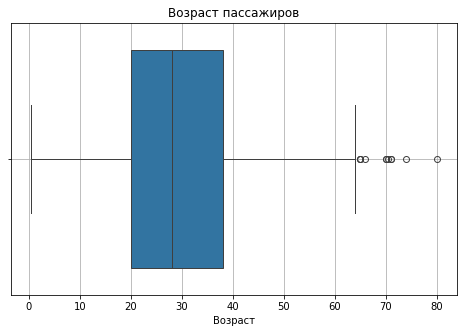

In [8]:
fig, ax = plt.subplots(figsize=(8,5))

sns.boxplot(x=df['Age'])
ax.set_title("Возраст пассажиров")
ax.set_xlabel("Возраст")
ax.grid(True)
print("""Медианой выборки является возраст 28 лет.
Возраст 50% пассажиров находится в диапазоне от 20 до 38 лет.
Соответственно, пассажиры младше 20 и старше 38 лет занимают по 25% от всей выборки.
Выбросами являются значения от 65 до 80. Человеческий возраст действительно может принимать такие значения, следовательно
пассажиры данного возраста присутствовали, но в малом количестве.
Разная длина усов говорит о том, что среди пассажиров больше детей и молодых людей, чем людей среднего и пожилого возраста.""")


Text(0.5, 1.0, 'Выживаемость пассажиров')

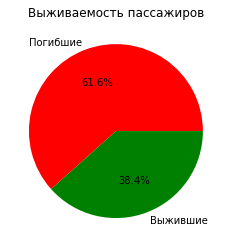

In [9]:
a = df.groupby(['Survived'])['PassengerId'].count()
a = a.rename({0: 'Погибшие', 1: 'Выжившие'})
a.index.to_list()
fig, ax = plt.subplots()
ax.pie(a.to_list(), labels=a.index.to_list(), autopct= '%1.1f%%', colors = ['red', 'green'])
ax.set_title('Выживаемость пассажиров')

Text(0.5, 1.0, 'Пассажирский класс')

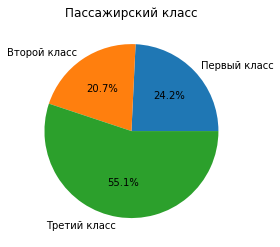

In [10]:
a = df.groupby(['Pclass'])['PassengerId'].count()
a = a.rename({1: 'Первый класс', 2: 'Второй класс', 3: 'Третий класс'})
a.index.to_list()
fig, ax = plt.subplots()
ax.pie(a.to_list(), labels=a.index.to_list(), autopct= '%1.1f%%')
ax.set_title('Пассажирский класс')

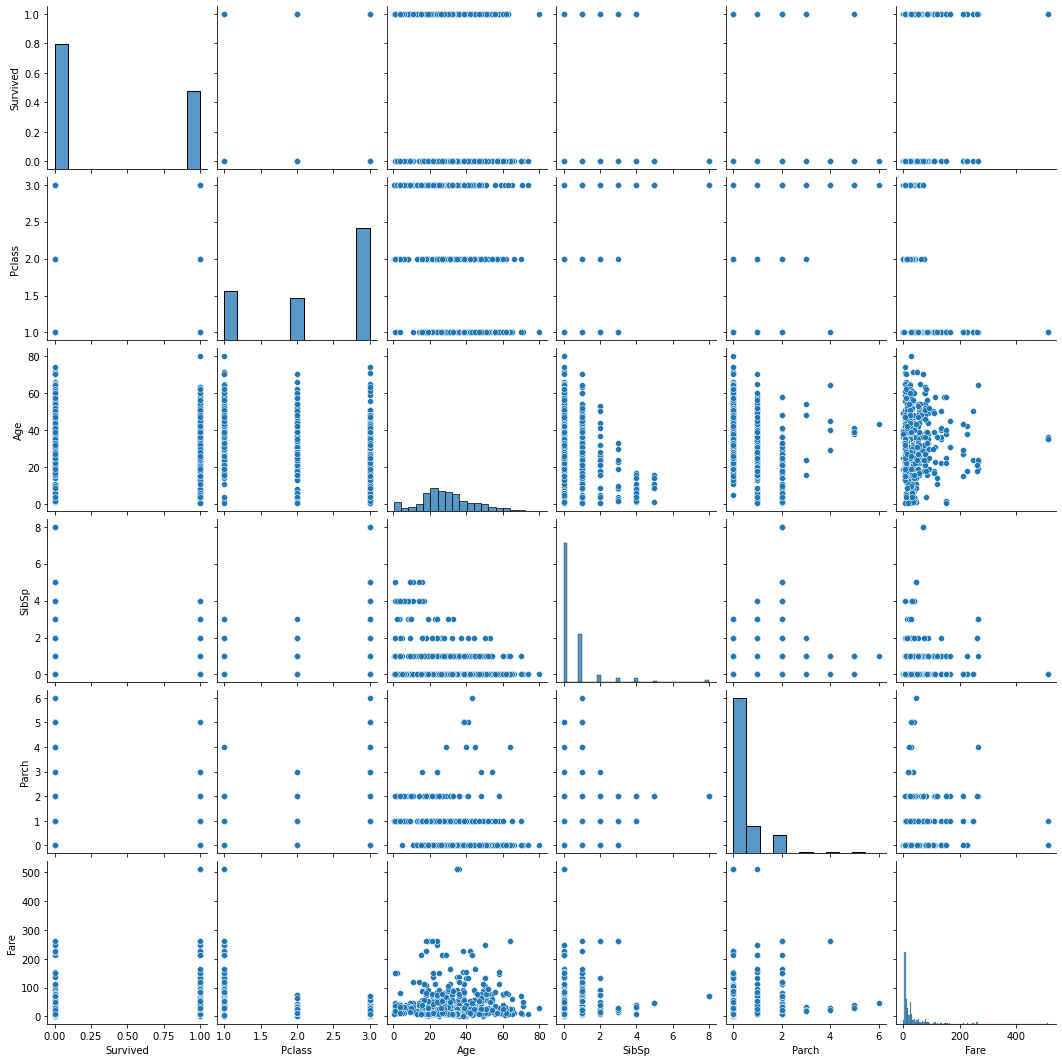

In [11]:
sns.pairplot(df, vars=["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"])

In [14]:
a = df.groupby(['Pclass'])['PassengerId'].count()
b = df.groupby(['Pclass', 'Sex'])['PassengerId'].count()

data = dict(
    categories = ['1 класс', '2 класс', '3 класс', 'Женщины (1 класс)', 'Мужчины (1 класс)', 'Женщины (2 класс)', 'Мужчины (2 класс)', 'Женщины (3 класс)', 'Мужчины (3 класс)'],
    parent = ['', '', '', '1 класс', '1 класс', '2 класс', '2 класс', '3 класс', '3 класс'],
    value = a.to_list() + b.to_list()
)
fig = px.sunburst(data, names='categories', parents = 'parent', values='value', branchvalues='total', title='Распределение мужчин и женщин по пассажирскому классу')
fig.write_html("Sunburst_Titanic.html", include_plotlyjs='cdn')
fig.show()

In [15]:
from IPython.display import IFrame
IFrame("Sunburst_Titanic.html", width=900, height=600)